<a href="https://colab.research.google.com/github/fadeeva/portfoli_o_o_ptimisation/blob/main/Step_02__Classical_Markowitz%20_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

from scipy import optimize

import datetime as dt
import yfinance as yf

import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('ggplot')

In [2]:
rng = np.random.default_rng(42)

# Classical Markowitz optimization

In [3]:
tickers  = ['AMD', 'AMZN', 'BAC', 'META', 'AVGO', 'TER', 'NVDA']

df = yf.download(tickers, dt.datetime(2022, 1, 1), dt.datetime.now(), auto_adjust=True)
df = df['Close']
df = pd.concat([df, df.pct_change().add_suffix('_simp_ret')], axis=1)
df.dropna(inplace=True)

df.head()

[*********************100%***********************]  7 of 7 completed


Ticker,AMD,AMZN,AVGO,BAC,META,NVDA,TER,AMD_simp_ret,AMZN_simp_ret,AVGO_simp_ret,BAC_simp_ret,META_simp_ret,NVDA_simp_ret,TER_simp_ret
Date,,,,,,,,,,,,,,
2022-01-04,144.419998,167.522003,62.018631,42.882721,333.600464,29.197758,163.409256,-0.038738,-0.016916,0.011458,0.039195,-0.005937,-0.027589,0.001625
2022-01-05,136.149994,164.356995,59.437756,42.158913,321.348083,27.517071,157.388733,-0.057264,-0.018893,-0.041615,-0.016879,-0.036728,-0.057562,-0.036843
2022-01-06,136.229996,163.253998,58.885891,43.007809,329.565857,28.089260,160.561035,0.000588,-0.006711,-0.009285,0.020136,0.025573,0.020794,0.020156
2022-01-07,132.000000,162.554001,57.233105,43.946068,328.901764,27.161194,155.444077,-0.031050,-0.004288,-0.028068,0.021816,-0.002015,-0.033040,-0.031869
2022-01-10,132.000000,161.485992,57.418900,43.722672,325.214142,27.313711,153.813721,0.000000,-0.006570,0.003246,-0.005083,-0.011212,0.005615,-0.010488


## Weighted Portfolio Return

In [6]:
amounts = rng.integers(low=10, high=50, size=len(tickers))
amounts

array([38, 41, 30, 15, 43, 28, 30])

In [26]:
position = df[tickers] * amounts
weights = position.div(position.sum(axis=1), axis=0)
weights.iloc[-1]

,2026-06-18
Ticker,
AMD,0.264116
AMZN,0.130348
BAC,0.022076
META,0.112915
AVGO,0.230148
TER,0.158062
NVDA,0.082335


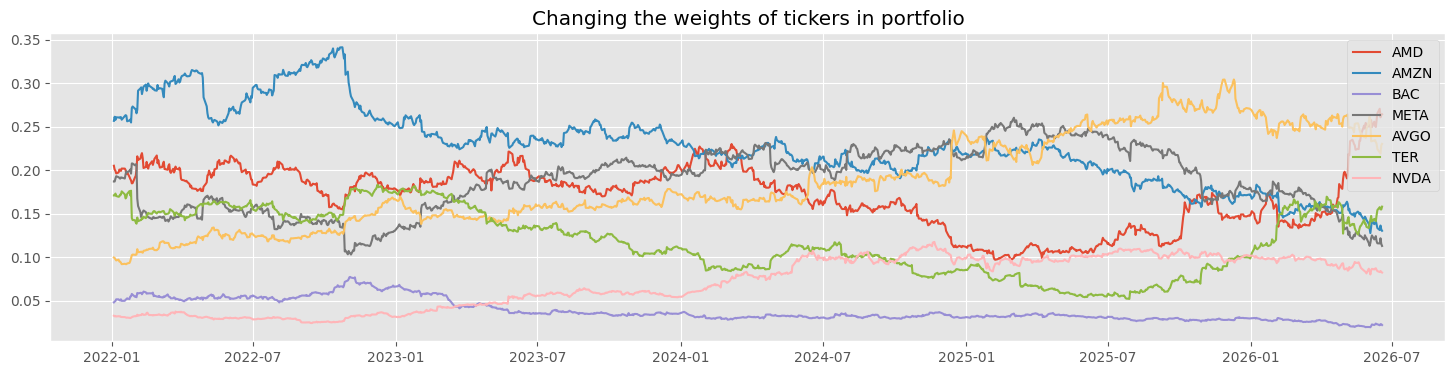

In [32]:
plt.figure(figsize=(18, 4))

plt.plot(weights, label=tickers)
plt.title('Changing the weights of tickers in portfolio')
plt.legend()